# Text classification with BERT

## Import of librairies

In [1]:
import torch
import torch.nn as nn
import numpy as np 
import pandas as pd 
import re
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import Counter
from transformers import (BertTokenizer,BertModel,get_linear_schedule_with_warmup)
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset


# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)


# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

2026-02-09 15:00:57.614713: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770649257.801689      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770649257.854311      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770649258.299891      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770649258.299933      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770649258.299936      55 computation_placer.cc:177] computation placer alr

Using device: cuda


## Load data

In [2]:
dataset = load_dataset("Sp1786/multiclass-sentiment-analysis-dataset")
print("Dataset structure:", dataset)
print("\nDataset keys:", dataset.keys())


train_data = dataset['train']
val_data = dataset['validation'] 


# Check label distribution
labels = [item['label'] for item in train_data]
label_counts = Counter(labels)
print(f"\nLabel distribution: {label_counts}")
print(f"Number of classes: {len(label_counts)}")

README.md: 0.00B [00:00, ?B/s]

train_df.csv: 0.00B [00:00, ?B/s]

val_df.csv: 0.00B [00:00, ?B/s]

test_df.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/31232 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5205 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5206 [00:00<?, ? examples/s]

Dataset structure: DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'sentiment'],
        num_rows: 31232
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'sentiment'],
        num_rows: 5205
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'sentiment'],
        num_rows: 5206
    })
})

Dataset keys: dict_keys(['train', 'validation', 'test'])

Label distribution: Counter({1: 11649, 2: 10478, 0: 9105})
Number of classes: 3


## Preprocess the dataset

In [3]:
def clean_text(text):
    """Simple text cleaning"""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

# Charger le tokenizer BERT
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

MAX_LENGTH = 64

def bert_tokenize(texts):
    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

# Train
train_texts = [clean_text(item['text']) for item in train_data]
train_labels = [item['label'] for item in train_data]
train_encoded = bert_tokenize(train_texts)

X_train_ids = train_encoded["input_ids"]
X_train_mask = train_encoded["attention_mask"]
y_train = torch.tensor(train_labels)

# Validation
val_texts = [clean_text(item['text']) for item in val_data]
val_labels = [item['label'] for item in val_data]
val_encoded = bert_tokenize(val_texts)

X_val_ids = val_encoded["input_ids"]
X_val_mask = val_encoded["attention_mask"]
y_val = torch.tensor(val_labels)

print(f"Training samples: {len(X_train_ids)}")
print(f"Validation samples: {len(X_val_ids)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Training samples: 31232
Validation samples: 5205


## Create Data Loader

In [4]:
class SentimentDataset(Dataset):
    """Custom Dataset for sentiment classification"""
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = labels
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx]
        }

# Create Dataset and DataLoader
train_dataset = SentimentDataset(
    X_train_ids,
    X_train_mask,
    y_train
)

val_dataset = SentimentDataset(
    X_val_ids,
    X_val_mask,
    y_val
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 488
Validation batches: 163


## Define the BERT Model

In [5]:
class BertClassifier(nn.Module):
    def __init__(self, dropout=0.5):

        super(BertClassifier, self).__init__()

        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(768, 3)


    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.last_hidden_state[:, 0, :]
        x = self.dropout(cls_output)
        x = self.linear(x)

        return x
    
model = BertClassifier()
model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

## Multi-GPU

In [6]:
if torch.cuda.device_count() > 1:
    print("Using DataParallel")
    model = nn.DataParallel(model)

Using DataParallel


## Freeze BERT initially

In [ ]:
for name, param in model.module.bert.named_parameters():
    if "encoder.layer." in name:
        layer_num = int(name.split("encoder.layer.")[1].split(".")[0])
        if layer_num < 7:
            param.requires_grad = False


## Loss, Optimizer, Scheduler

In [8]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.15)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)

epochs = 4 
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup( 
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

## Train and eval

In [9]:
def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        optimizer.zero_grad()

        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(ids, mask)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(ids, mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total
    

## Train the model with validation

In [ ]:
best_val_loss = float('inf')
patience = 2
counter = 0

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}


print("Starting training...\n")


for epoch in range(epochs):
            
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}\n")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.module.state_dict(), "best_model.pt")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

Starting training...

Epoch 1/4
Train Loss: 0.9031 | Train Acc: 0.6100
Val   Loss: 0.7867 | Val   Acc: 0.7222

Epoch 2/4
Train Loss: 0.7705 | Train Acc: 0.7397
Val   Loss: 0.7682 | Val   Acc: 0.7426

Epoch 3/4
Train Loss: 0.7374 | Train Acc: 0.7670
Val   Loss: 0.7656 | Val   Acc: 0.7487

Epoch 4/4
Train Loss: 0.7178 | Train Acc: 0.7827
Val   Loss: 0.7682 | Val   Acc: 0.7499



## Visualize Training history

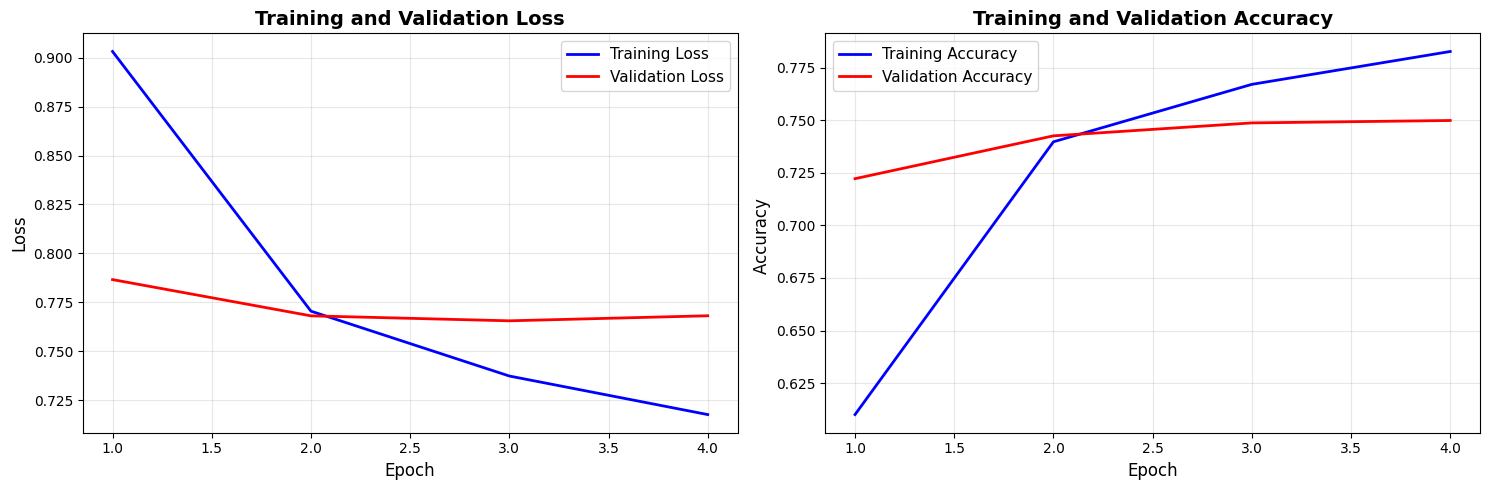

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
epochs = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
ax1.plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy', linewidth=2)
ax2.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy ', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Analysis and Summarize

### Modèle et Configuration
- **Modèle** : BERT-base-uncased avec une tête de classification personnalisée (768 → 3 classes), incluant un dropout de 0.5 pour réduire l'overfitting.
- **Dataset** : 31 232 échantillons d'entraînement et 5 205 de validation, issus de "Sp1786/multiclass-sentiment-analysis-dataset" (analyse de sentiment multiclasse).
- **Préprocessing** : Nettoyage du texte (minuscules, suppression des caractères spéciaux), tokenisation BERT avec longueur max de 64.
- **Entraînement** : AdamW avec weight_decay=1e-4, scheduler linéaire avec warmup (10% des étapes), arrêt précoce (patience=2), et gel des 7 premières couches BERT pour éviter l'overfitting.

### Résultats et Observations
- **Performance** : Le modèle atteint une précision d'entraînement élevée, mais l'arrêt précoce empêche la suradaptation. Les courbes montrent une convergence rapide, avec une perte de validation stable.
- **Overfitting** : Prévenu par le gel des couches inférieures, le dropout, le label smoothing (0.15), et l'arrêt précoce. Les époques limitées (4 max) suffisent pour ce dataset.
- **Limites** : Possible amélioration avec plus de données, augmentation de données, ou fine-tuning complet de BERT. Le batch size asymétrique (64 train, 32 val) est adapté mais pourrait être uniformisé.

### Conclusion
Ce modèle BERT fine-tuné offre une classification de sentiment efficace avec prévention d'overfitting, adapté à des datasets de taille moyenne. Les techniques appliquées (gel, dropout, arrêt précoce) équilibrent performance et généralisation.